   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 49.8 MB/s eta 0:00:00
Mounted at /content/drive
Loading xx...
Loading yy...
Loading oilMask...
Loading sigma_naught...
lon : (274, 392)
lat : (274, 392)
mask: (274, 392)
sar : (274, 392)


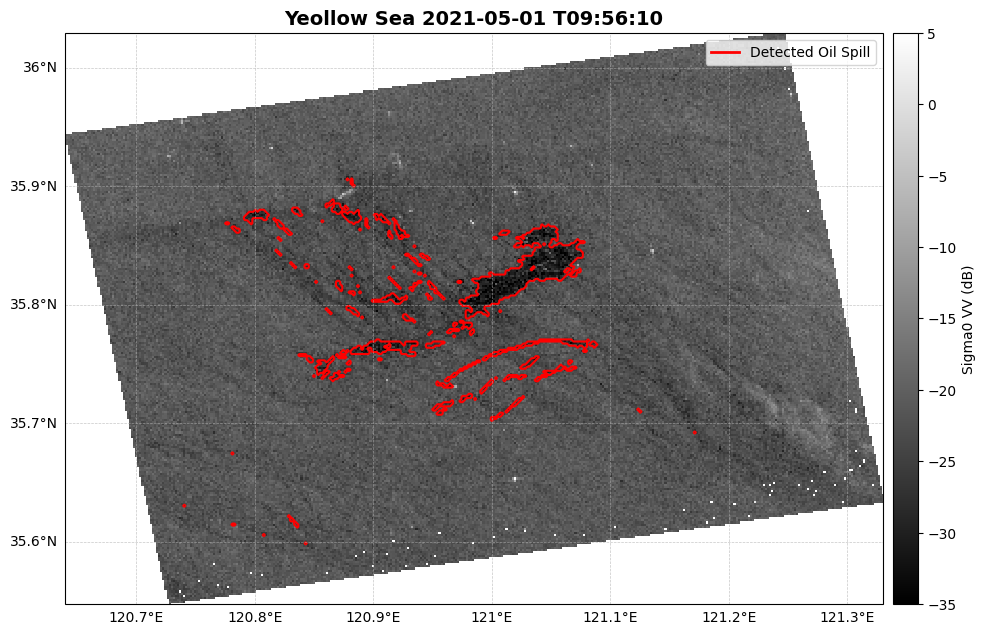

Saved figure: /content/drive/MyDrive/SAR_AI_Oil_Spill_Detection/stage2_yellow_sea_finetuning.png


In [ ]:
# ============================================================
# visualize_georeferenced_result.ipynb

# Visualize DeepLabV3 oil-spill detection results on georeferenced Sentinel-1 SAR imagery.

# This script overlays the predicted oil-spill mask on a Sentinel-1 Sigma0 VV image
# using longitude and latitude grids stored in a MATLAB .mat file.

# Input:
#     - Result .mat file containing:
#         xx
#         yy
#         oilMask

#     - Sentinel-1 .mat file containing:
#         sigma_naught

# Output:
#     - Georeferenced PNG figure

# For non-v7.3 MAT files

# ============================================================

!pip install cartopy -q

import os
import gc
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from google.colab import drive
drive.mount('/content/drive')

from mpl_toolkits.axes_grid1 import make_axes_locatable

# ============================================================
# File paths
# ============================================================

resultFile = "/content/drive/MyDrive/SAR_AI_Oil_Spill_Detection/Yeollow_Sea_20210501T095610_DeeplabV3_finetuend.mat"

sarFile = "/content/drive/MyDrive/SAR_AI_Oil_Spill_Detection/Yeollow_Sea_S1A_IW_GRDH_1SDV_20210501T095610.mat"

saveFigPath = "/content/drive/MyDrive/SAR_AI_Oil_Spill_Detection/stage2_yellow_sea_finetuning.png"

ds = 16

# ============================================================
# Load variables one by one
# ============================================================

print("Loading xx...")
xx = loadmat(resultFile, variable_names=["xx"])["xx"]
lon = xx[::ds, ::ds].astype(np.float32)
del xx
gc.collect()

print("Loading yy...")
yy = loadmat(resultFile, variable_names=["yy"])["yy"]
lat = yy[::ds, ::ds].astype(np.float32)
del yy
gc.collect()

print("Loading oilMask...")
oilMask = loadmat(resultFile, variable_names=["oilMask"])["oilMask"]
mask = oilMask[::ds, ::ds].astype(np.uint8)
del oilMask
gc.collect()

print("Loading sigma_naught...")
sigma = loadmat(sarFile, variable_names=["sigma_naught"])["sigma_naught"]
sar = sigma[::ds, ::ds].astype(np.float32)
del sigma
gc.collect()

sar = np.clip(sar, -35, 5)

# ============================================================
# Match array sizes
# ============================================================

nrow = min(lon.shape[0], lat.shape[0], mask.shape[0], sar.shape[0])
ncol = min(lon.shape[1], lat.shape[1], mask.shape[1], sar.shape[1])

lon = lon[:nrow, :ncol]
lat = lat[:nrow, :ncol]
mask = mask[:nrow, :ncol]
sar = sar[:nrow, :ncol]

print("lon :", lon.shape)
print("lat :", lat.shape)
print("mask:", mask.shape)
print("sar :", sar.shape)

# ============================================================
# Plot
# ============================================================

fig = plt.figure(figsize=(11, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([
    np.nanmin(lon), np.nanmax(lon),
    np.nanmin(lat), np.nanmax(lat)
], crs=ccrs.PlateCarree())

# SAR background
im = ax.pcolormesh(
    lon,
    lat,
    sar,
    cmap="gray",
    shading="auto",
    transform=ccrs.PlateCarree()
)

# Oil detection contour
ax.contour(
    lon,
    lat,
    mask,
    levels=[0.5],
    colors="red",
    linewidths=1.5,
    transform=ccrs.PlateCarree()
)


# ==========================
# Legend
# ==========================
from matplotlib.lines import Line2D

oil_legend = Line2D(
    [0], [0],
    color='red',
    lw=2,
    label='Detected Oil Spill'
)

ax.legend(
    handles=[oil_legend],
    loc='upper right',
    fontsize=10,
    frameon=True
)

# Gridlines
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    linestyle="--",
    alpha=0.7
)

gl.top_labels = False
gl.right_labels = False

plt.title(
    "Yeollow Sea 2021-05-01 T09:56:10",
    fontsize=14,
    fontweight="bold"
)

divider = make_axes_locatable(ax)

cax = divider.append_axes(
    "right",
    size="3%",
    pad=0.10,
    axes_class=plt.Axes
)

cbar = plt.colorbar(im, cax=cax)

cbar.set_label("Sigma0 VV (dB)")

plt.savefig(saveFigPath, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", saveFigPath)